# Test ispezione, raffinamento e marcatura

Workflow:
1. import del modulo;
2. inizializzazione ZED/robot;
3. ispezione globale;
4. raffinamento;
5. marcatura controllata;

## 1 — Import del modulo

Questa cella importa `inspection_and_marking.py`.

`importlib.reload(im)` serve per ricaricare il file `.py` se lo modifichi in VSCode durante la sessione notebook.

**Nota:** dopo `reload`, i parametri tornano ai valori scritti nel file `.py`, quindi la cella successiva li risetta per il tuning.

In [1]:
import importlib
import numpy as np
import time
import matplotlib.pyplot as plt

import inspection_and_marking as im
import Variables as vb

im = importlib.reload(im)

print("Modulo inspection_and_marking importato e ricaricato.")

Modulo inspection_and_marking importato e ricaricato.


## 2 — Inizializzazione robot + ZED

**Attenzione: muove il robot** verso la posizione iniziale.

In [2]:
# Se non hai già inizializzato la ZED nella cella precedente, lascia questa parte attiva.
if "zed" not in globals():
    zed, runtime, image_zed, point_cloud = im.init_zed()
    print("ZED inizializzata.")
else:
    print("ZED già inizializzata.")

ZED inizializzata.


In [3]:
controller = im.RobotController(
    ip_address=im.IP_ROBOT,
    default_position_j=vb.LOOK_DOWN_POSITION_J_INIZIO
)

controller.connect()
print("Robot connesso.")

[15:04:04] INFO     Succesfully connected to robot Ethernet Slave and Modbus.                         techman.py:25

           INFO     Connected to Listen Node                                                          techman.py:37

Robot connesso.


In [4]:
# posizionamento iniziale
controller.default_positioning()
print("Robot in posizione iniziale.")

im.move_to_hub(controller)

Robot in posizione iniziale.
Ritorno alla posizione di hub [0, 0, 90].
  [SAFETY] Traiettoria non sicura. Deviazione tramite l'apice del casco.
  [CIRCLE] Movimento sferico: (1.6°, 120.1°) -> (0.0°, 90.0°)
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).


### Scelta parametri aggiuntivi

Scegliamo se utilizzare l'identificazione di difetti di colore generico e se richiedere conferma prima di effettuare il marking di un difetto

In [5]:
REQUIRE_INPUT = False

In [6]:
# Switch per attivare/disattivare l'identificazione dei difetti generici
im.GENERIC_DETECTION = True

print("Rilevamento generico dei difetti attivo.\n Attivazione dell'attention radius")

if im.GENERIC_DETECTION:
    print("Rilevamento generico dei difetti attivo.\n Attivazione dell'attention radius")
    im.GLOBAL_ATTENTION_RADIUS = 400 # Tuning: con detection generica serve un po' di attenzione per evitare falsi positivi ai bordi.
else:
    print("Rilevamento generico dei difetti disattivato.")
    im.GLOBAL_ATTENTION_RADIUS = None

Rilevamento generico dei difetti attivo.
 Attivazione dell'attention radius
Rilevamento generico dei difetti attivo.
 Attivazione dell'attention radius


## 3 — Ispezione globale completa

Avvia il movimento della telecaera in posizoni predefinite in cui scattare delle foto ed identificare tutti i difetti presenti sul casco.

Ad ogni foto viene mostrata l'immagine di debug ed un elenco dei difetti identificati nella foto.

In [7]:
start_timer = time.time()

=== ISPEZIONE GLOBALE ===
Numero posizioni di ispezione: 7
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).

------------------------------------------------------------
Scatto 1/7
Posizione sferica: [300, 0, 90]
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti trovati in questo scatto: 2
      Scatto 1 - difetto 1 rilevato:
        centroid: [819 289]
        area: 1529.0
        pos3d_camera: [ 44.3 -16.2 162.3]
        Z camera: 162.3 mm
        radial camera: 47.2 mm
        pos3d_global: [ 43.1 677.8 387.7]
        sph_coord [r, alpha, beta]: [222.7  11.5  85.8]
      Scatto 1 - difetto 2 rilevato:
        centroid: [336 191]
        area: 1482.5
        pos3d_camera: [-71.6 -43.2 185.1]
        Z camera: 185.1 mm
        radial camera: 83.6 mm
        pos3d_global: [-72.7 704.8 364.9]
        sph_coord [r, alpha, beta]: [212.  -20.2  

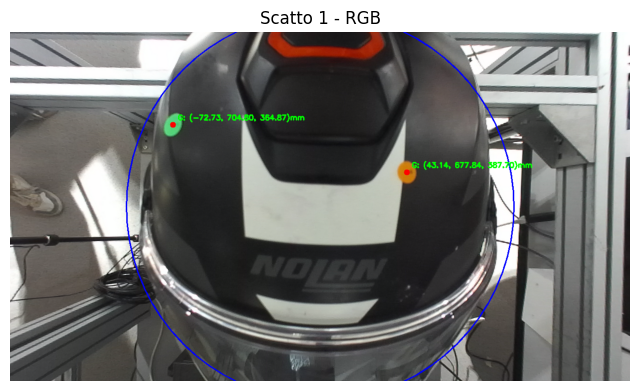

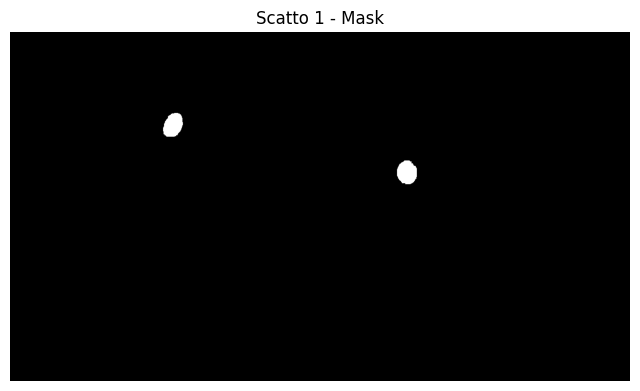


------------------------------------------------------------
Scatto 2/7
Posizione sferica: [300, 0, 45]
  [CIRCLE] Movimento sferico: (-0.0°, 90.0°) -> (0.0°, 45.0°)
Difetti trovati in questo scatto: 0


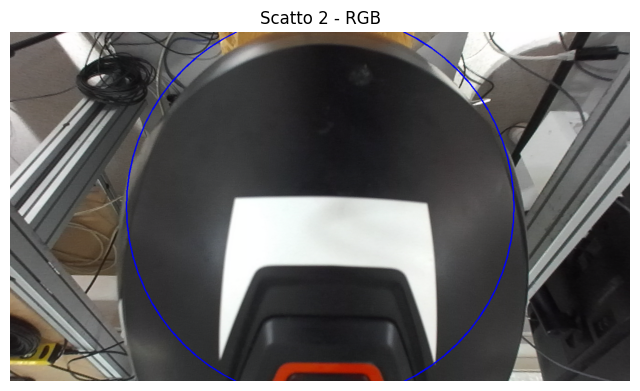

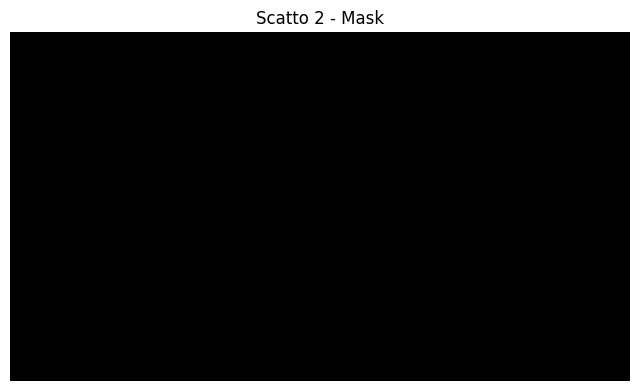


------------------------------------------------------------
Scatto 3/7
Posizione sferica: [300, 0, 25]
  [CIRCLE] Movimento sferico: (-0.0°, 45.0°) -> (0.0°, 25.0°)
Difetti trovati in questo scatto: 0


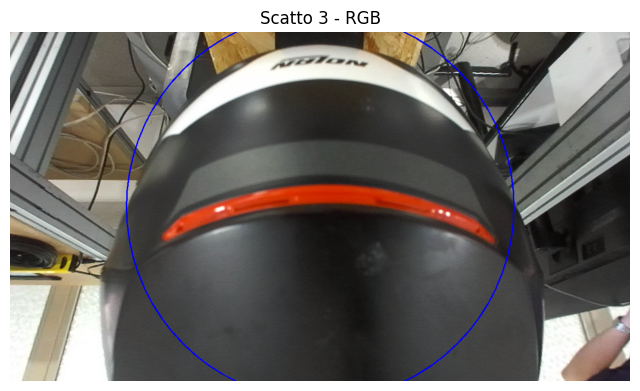

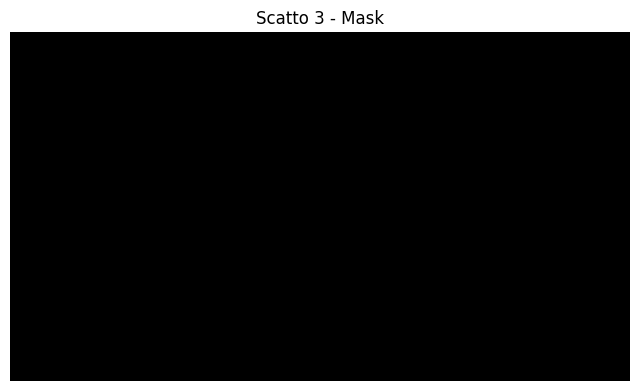


------------------------------------------------------------
Scatto 4/7
Posizione sferica: [300, 45, 45]
  [CIRCLE] Movimento sferico: (-0.0°, 25.0°) -> (45.0°, 45.0°)
Difetti trovati in questo scatto: 1
      Scatto 4 - difetto 1 rilevato:
        centroid: [678  17]
        area: 1088.5
        pos3d_camera: [ 12.8 -74.2 157.6]
        Z camera: 157.6 mm
        radial camera: 75.3 mm
        pos3d_global: [ 52.  829.  205.1]
        sph_coord [r, alpha, beta]: [179.   56.5  20.8]


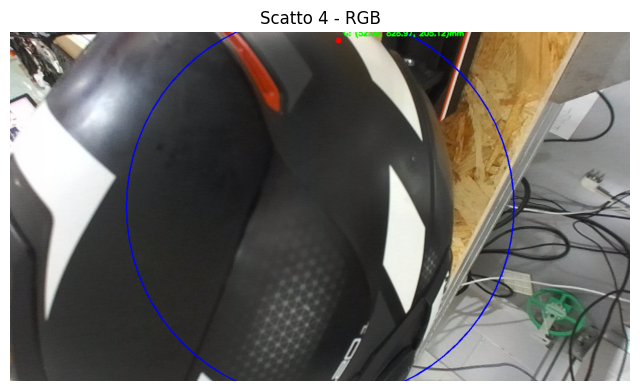

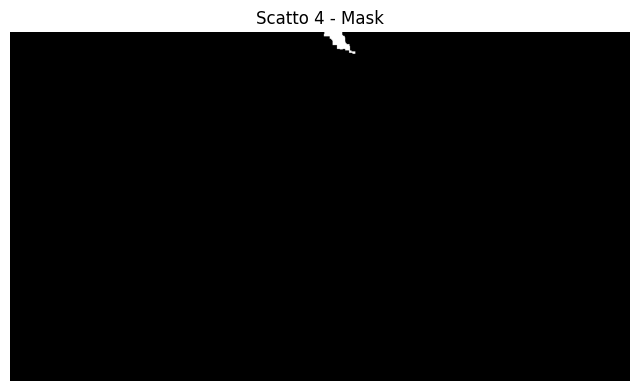


------------------------------------------------------------
Scatto 5/7
Posizione sferica: [300, 40, 80]
  [CIRCLE] Movimento sferico: (45.0°, 45.0°) -> (40.0°, 80.0°)
Difetti trovati in questo scatto: 1
      Scatto 5 - difetto 1 rilevato:
        centroid: [540 191]
        area: 1610.5
        pos3d_camera: [-15.6 -34.  145.6]
        Z camera: 145.6 mm
        radial camera: 37.4 mm
        pos3d_global: [109.6 729.9 326.3]
        sph_coord [r, alpha, beta]: [203.4  35.3  70.4]


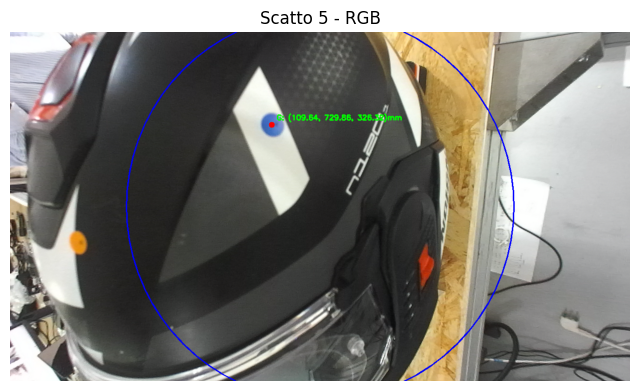

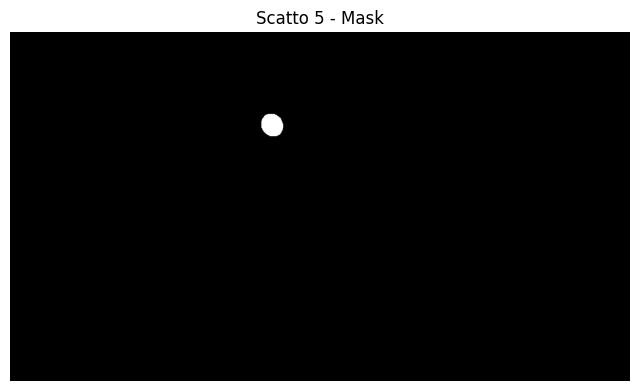


------------------------------------------------------------
Scatto 6/7
Posizione sferica: [300, -40, 80]
  [CIRCLE] Movimento sferico: (40.0°, 80.0°) -> (-40.0°, 80.0°)
Difetti trovati in questo scatto: 1
      Scatto 6 - difetto 1 rilevato:
        centroid: [953 311]
        area: 3349.0
        pos3d_camera: [ 63.9  -9.7 140. ]
        Z camera: 140.0 mm
        radial camera: 64.6 mm
        pos3d_global: [-81.2 706.9 364.8]
        sph_coord [r, alpha, beta]: [215.4 -22.3  77.9]


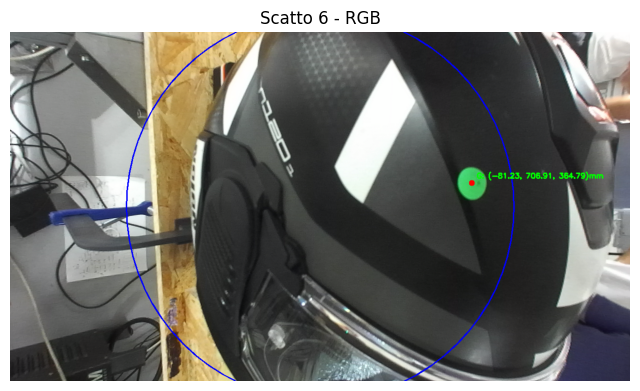

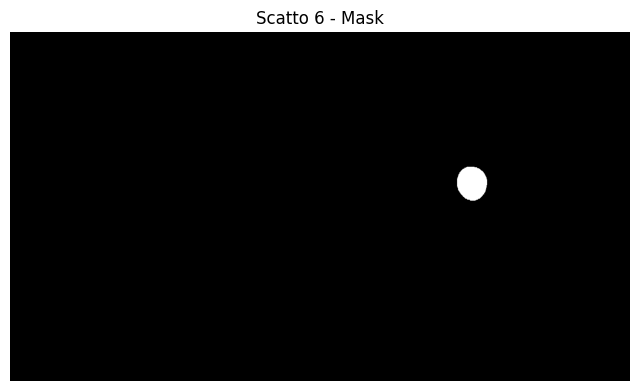


------------------------------------------------------------
Scatto 7/7
Posizione sferica: [300, -45, 45]
  [CIRCLE] Movimento sferico: (-40.0°, 80.0°) -> (-45.0°, 45.0°)
Difetti trovati in questo scatto: 0


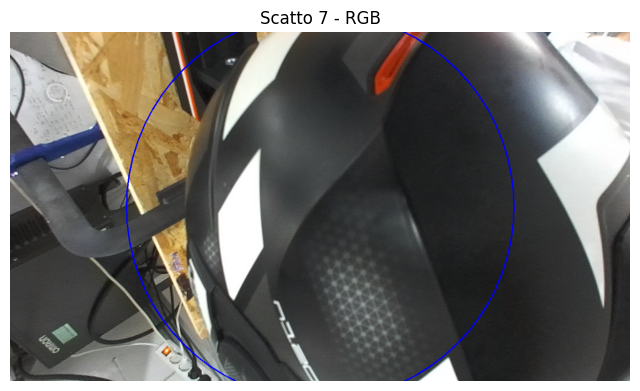

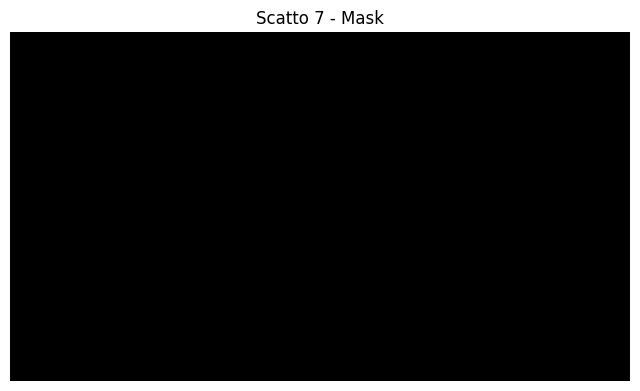

In [8]:
all_defects = []

INSPECTION_POSITIONS = [
    [im.INSPECTION_RADIUS,   0, 90],   # alto
    [im.INSPECTION_RADIUS,   0, 45],   # frontale/intermedio
    [im.INSPECTION_RADIUS,   0, 25],   # frontale/intermedio
    [im.INSPECTION_RADIUS,  45, 45],   # laterale destro
    [im.INSPECTION_RADIUS,  40, 80],   # laterale destro avanti
    [im.INSPECTION_RADIUS, -40, 80],   # laterale sinistro avanti
    [im.INSPECTION_RADIUS, -45, 45],   # laterale sinistro
]

#INSPECTION_POSITIONS = [[im.INSPECTION_RADIUS, 0, 90]]

# commenta se vuoi usare delle posizoni personalizzate, altrimenti usa quelle di default
# INSPECTION_POSITIONS = im.INSPECTION_POSITIONS

print("=== ISPEZIONE GLOBALE ===")
print(f"Numero posizioni di ispezione: {len(INSPECTION_POSITIONS)}")

im.move_to_hub(controller)

for i, inspection_position in enumerate(INSPECTION_POSITIONS):

    print("\n" + "-" * 60)
    print(f"Scatto {i + 1}/{len(INSPECTION_POSITIONS)}")
    print(f"Posizione sferica: {inspection_position}")

    defect_list, debug_img, mask_bgr, bgr_image = im.point_and_shoot(
        controller=controller,
        zed=zed,
        runtime=runtime,
        image_zed=image_zed,
        point_cloud=point_cloud,
        test_sph=inspection_position,
        #insp_radius=im.INSPECTION_RADIUS,           # è già così di default ma non si sa mai
        helmet_center=vb.HELMET_CENTER_GLOBAL
    )

    print(f"Difetti trovati in questo scatto: {len(defect_list)}")

    for idx, d in enumerate(defect_list):
        d.say_hi(Name=f"Scatto {i + 1} - difetto {idx + 1}")

    all_defects.extend(defect_list)

    im.show_debug_matplotlib(
        debug_img=debug_img,
        mask_bgr=mask_bgr,
        title=f"Scatto {i + 1}"
    )


### Filtraggio dei difetti duplicati

Diverse foto possono identificare lo stesso difetto da angolazioni diverse, perciò procediamo al filtraggio dei difetti duplicati.

Il filtraggio avviene in base posizione globale: se la distanza euclidea tra le posizioni globali di due difetti è inferiore ad un certo threshold vuol dire che i due oggetti identificano lo stesso difetto, manteniamo quindi l'oggetto con l'area maggiore, ossia quello in cui il difetto è stato identifcato in modo perpendicolare.

In [9]:
print("\n=== ISPEZIONE COMPLETATA ===")
print(f"Difetti totali prima del filtro duplicati: {len(all_defects)}")

unique_defects = im.duplicate_filter(
    all_defects,
    distance_threshold=im.DUPLICATE_DISTANCE
)

print(f"Difetti univoci dopo filtro duplicati: {len(unique_defects)}")


for idx, d in enumerate(unique_defects):
    d.say_hi(Name=f"Difetto unico {idx + 1}")

print("\nRitorno all'hub...")
im.move_to_hub(controller)


=== ISPEZIONE COMPLETATA ===
Difetti totali prima del filtro duplicati: 5
Difetti univoci dopo filtro duplicati: 4
      Difetto unico 1 rilevato:
        centroid: [819 289]
        area: 1529.0
        pos3d_camera: [ 44.3 -16.2 162.3]
        Z camera: 162.3 mm
        radial camera: 47.2 mm
        pos3d_global: [ 43.1 677.8 387.7]
        sph_coord [r, alpha, beta]: [222.7  11.5  85.8]
      Difetto unico 2 rilevato:
        centroid: [953 311]
        area: 3349.0
        pos3d_camera: [ 63.9  -9.7 140. ]
        Z camera: 140.0 mm
        radial camera: 64.6 mm
        pos3d_global: [-81.2 706.9 364.8]
        sph_coord [r, alpha, beta]: [215.4 -22.3  77.9]
      Difetto unico 3 rilevato:
        centroid: [678  17]
        area: 1088.5
        pos3d_camera: [ 12.8 -74.2 157.6]
        Z camera: 157.6 mm
        radial camera: 75.3 mm
        pos3d_global: [ 52.  829.  205.1]
        sph_coord [r, alpha, beta]: [179.   56.5  20.8]
      Difetto unico 4 rilevato:
        centroi

### Visualizzazione preliminare dei difetti unici identificati

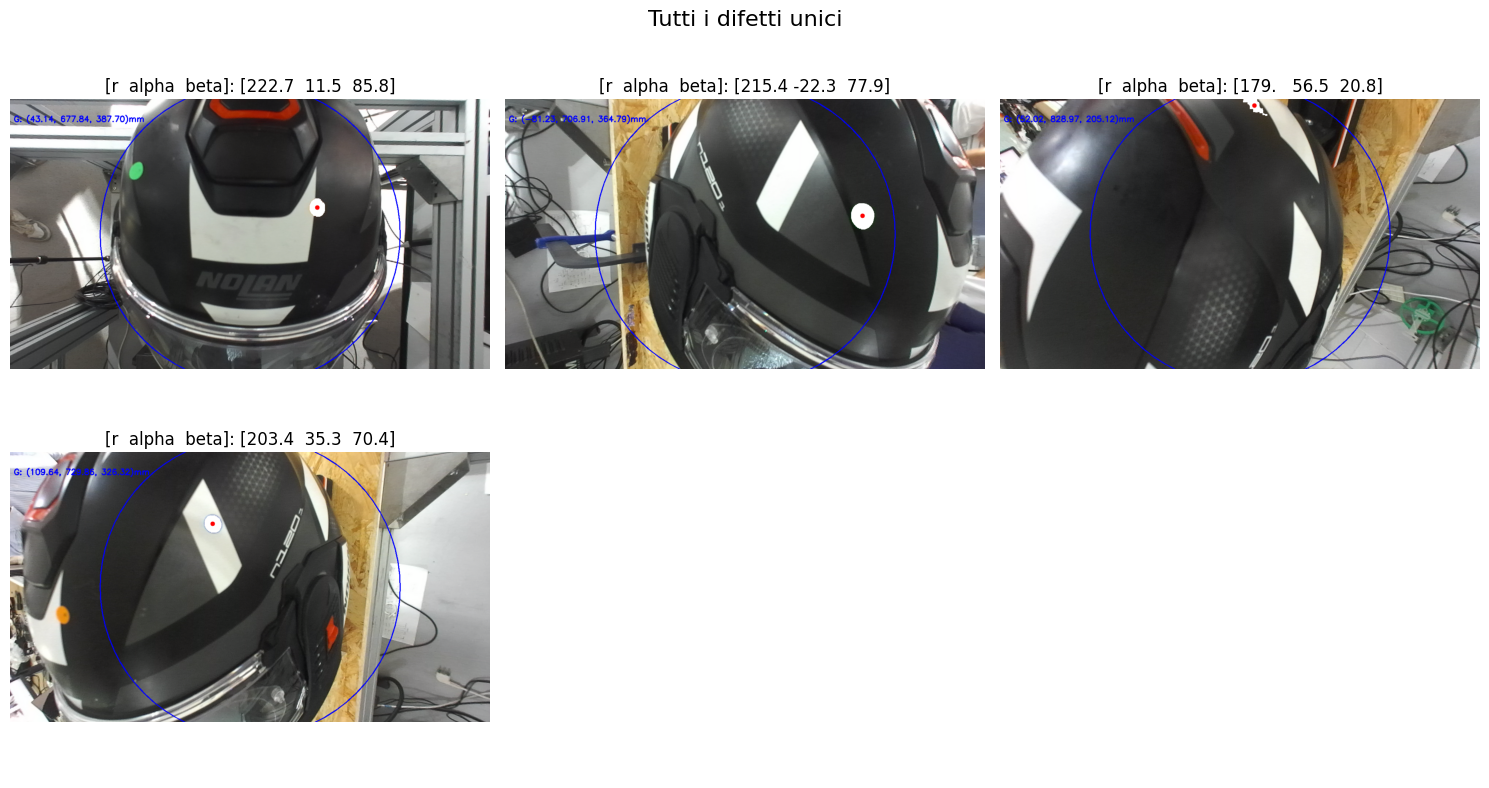

In [10]:
if len(unique_defects) == 0:
    print("Nessun difetto univoco da visualizzare.")
else:
    n_defects = len(unique_defects)
    cols = min(3, n_defects)
    rows = int(np.ceil(n_defects / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, d in zip(axes, unique_defects):
        img = d.img()
        if img is None:
            ax.axis("off")
            continue

        if img.ndim == 3 and img.shape[-1] == 3:
            img = img[..., ::-1]

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(f"[r  alpha  beta]: {np.round(d.sph_coord,1)}")
        ax.axis("off")

    for ax in axes[n_defects:]:
        ax.axis("off")

    fig.suptitle("Tutti i difetti unici", fontsize=16)
    plt.tight_layout()
    plt.show()

## 4 — Raffinamento e marking di ogni difetto

Procediamo quindi con il raffinamento della posizone di goni difetto identificato posizionandolo al centro dell'inquadratura ed effettuando letture multiple in modo da ottenere una posizione quanto più accurata possibile.

NB: se il difetto non viene identificato nella maggior parte degli scatti viene scartato, in quando è probabilmente causato da riflessi o errori di lettura.

Procediamo quindi al marking posizionando la punta del marker sul difetto, mantenendo l'oriantamento perpendicolare.

=== RAFFINAMENTO DI TUTTI I DIFETTI ===
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti da raffinare: 4

------------------------------------------------------------
Raffinamento difetto 1/4
      Difetto 1 prima del raffinamento rilevato:
        centroid: [819 289]
        area: 1529.0
        pos3d_camera: [ 44.3 -16.2 162.3]
        Z camera: 162.3 mm
        radial camera: 47.2 mm
        pos3d_global: [ 43.1 677.8 387.7]
        sph_coord [r, alpha, beta]: [222.7  11.5  85.8]


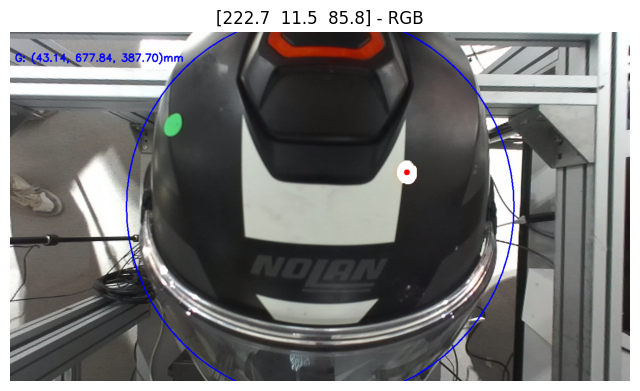

 Raffinamento difetto: r_stimato=222.7mm, alpha=11.5°, beta=85.8°
  [CIRCLE] Movimento sferico: (-0.0°, 90.0°) -> (11.5°, 85.8°)
  Movimento camera a r=<function variable_helmet_radius at 0x00000275458B8B40>mm nella direzione del difetto.
  [REFINE] Sicurezza difetto 10/10, difetto raffinato
  Raffinamento completato.
  Nuove coordinate sferiche:
    r=221.7 mm, alpha=12.0°, beta=85.6°
  Posizione vecchia: [ 43.1 677.8 387.7] mm
  Posizione nuova:   [ 44.6 678.8 386.3] mm
  Delta: 2.3 mm
Difetto 1 raffinato correttamente.
      Difetto 1 raffinato rilevato:
        centroid: [819 289]
        area: 1529.0
        pos3d_camera: [ 44.3 -16.2 162.3]
        Z camera: 162.3 mm
        radial camera: 47.2 mm
        pos3d_global: [ 44.6 678.8 386.3]
        sph_coord [r, alpha, beta]: [221.7  12.   85.6]
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=12.0°, beta=85.6°).
  Movimento camera nella direzione del difetto.
  Avvio marcatura difetto in [ 44.6 678.8 

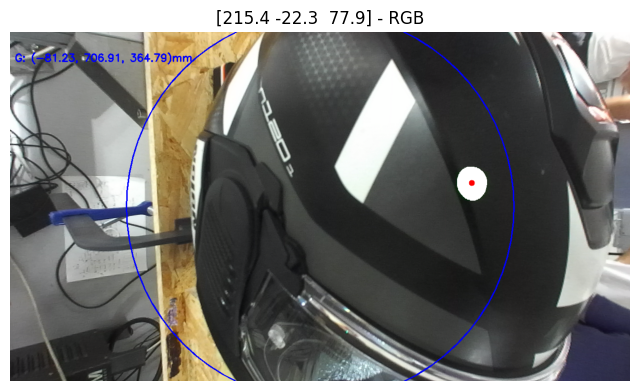

 Raffinamento difetto: r_stimato=215.4mm, alpha=-22.3°, beta=77.9°
  [CIRCLE] Movimento sferico: (12.0°, 85.6°) -> (-22.3°, 77.9°)
  Movimento camera a r=<function variable_helmet_radius at 0x00000275458B8B40>mm nella direzione del difetto.
  [REFINE] Sicurezza difetto 10/10, difetto raffinato
  Raffinamento completato.
  Nuove coordinate sferiche:
    r=214.4 mm, alpha=-21.4°, beta=77.7°
  Posizione vecchia: [-81.2 706.9 364.8] mm
  Posizione nuova:   [-77.7 707.2 365. ] mm
  Delta: 3.5 mm
Difetto 2 raffinato correttamente.
      Difetto 2 raffinato rilevato:
        centroid: [953 311]
        area: 3349.0
        pos3d_camera: [ 63.9  -9.7 140. ]
        Z camera: 140.0 mm
        radial camera: 64.6 mm
        pos3d_global: [-77.7 707.2 365. ]
        sph_coord [r, alpha, beta]: [214.4 -21.4  77.7]
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=-21.4°, beta=77.7°).
  Movimento camera nella direzione del difetto.
  Avvio marcatura difetto in [-77.7 70

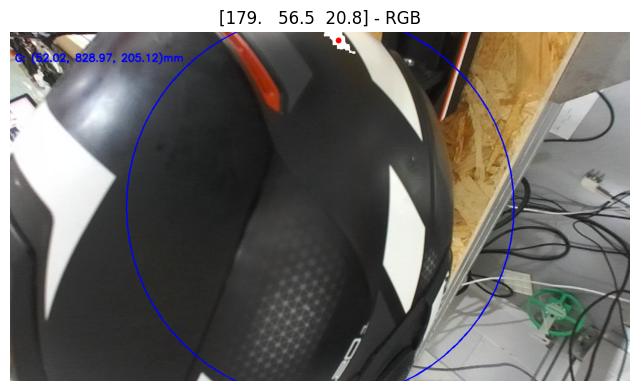

 Raffinamento difetto: r_stimato=179.0mm, alpha=56.5°, beta=20.8°
  [SKIP] Destinazione (alpha=56.5°, beta=20.8°) fuori limiti sicurezza.
  [SKIP] Impossibile raggiungere la posizione ravvicinata in sicurezza.
Difetto 3 scartato/non confermato/irraggiungibile.

------------------------------------------------------------
Raffinamento difetto 4/4
      Difetto 4 prima del raffinamento rilevato:
        centroid: [540 191]
        area: 1610.5
        pos3d_camera: [-15.6 -34.  145.6]
        Z camera: 145.6 mm
        radial camera: 37.4 mm
        pos3d_global: [109.6 729.9 326.3]
        sph_coord [r, alpha, beta]: [203.4  35.3  70.4]


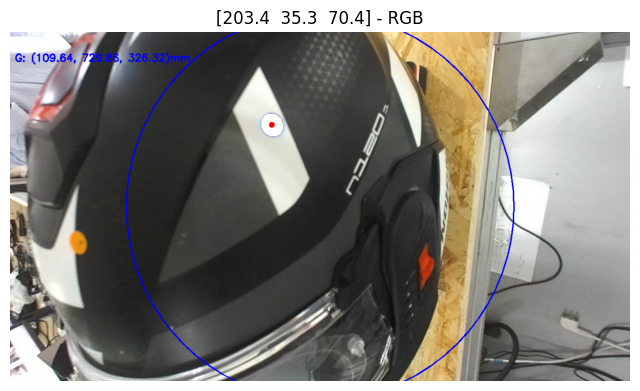

 Raffinamento difetto: r_stimato=203.4mm, alpha=35.3°, beta=70.4°
  [CIRCLE] Movimento sferico: (-21.4°, 77.7°) -> (35.3°, 70.4°)
  Movimento camera a r=<function variable_helmet_radius at 0x00000275458B8B40>mm nella direzione del difetto.
  [REFINE] Sicurezza difetto 10/10, difetto raffinato
  Raffinamento completato.
  Nuove coordinate sferiche:
    r=203.6 mm, alpha=35.0°, beta=69.9°
  Posizione vecchia: [109.6 729.9 326.3] mm
  Posizione nuova:   [108.5 731.5 326.7] mm
  Delta: 2.1 mm
Difetto 4 raffinato correttamente.
      Difetto 4 raffinato rilevato:
        centroid: [540 191]
        area: 1610.5
        pos3d_camera: [-15.6 -34.  145.6]
        Z camera: 145.6 mm
        radial camera: 37.4 mm
        pos3d_global: [108.5 731.5 326.7]
        sph_coord [r, alpha, beta]: [203.6  35.   69.9]
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=35.0°, beta=69.9°).
  Movimento camera nella direzione del difetto.
  Avvio marcatura difetto in [108.5 731.5

In [11]:
print("=== RAFFINAMENTO DI TUTTI I DIFETTI ===")
im.move_to_hub(controller)

refined_defects = []
marked_defects = []


print(f"Difetti da raffinare: {len(unique_defects)}")

for i, d in enumerate(unique_defects.copy()):  # Crea una copia per iterare

    print("\n" + "-" * 60)
    print(f"Raffinamento difetto {i + 1}/{len(unique_defects)}")

    d.say_hi(Name=f"Difetto {i + 1} prima del raffinamento")
    im.show_debug_matplotlib(d.img(), title=f"{np.round(d.sph_coord,1)}")

    if REQUIRE_INPUT:
        if input(f"\nPremi Invio per il raffinamento in posizione {np.round(d.sph_coord, 2)}") != "":
            print("raffinamento saltato.")
            continue
    
    success = im.refine_defect_position(
        controller=controller,
        zed=zed,
        runtime=runtime,
        image_zed=image_zed,
        point_cloud=point_cloud,
        defect_obj=d,
        helmet_center=vb.HELMET_CENTER_GLOBAL,
        generic_detection=im.GENERIC_DETECTION
    )

    if success:
        print(f"Difetto {i + 1} raffinato correttamente.")
        d.say_hi(Name=f"Difetto {i + 1} raffinato")
        refined_defects.append(d)
    else:
        print(f"Difetto {i + 1} scartato/non confermato/irraggiungibile.")
        continue
    
    success = im.mark_defect(
            controller=controller,
            defect_obj=d,
            helmet_center=vb.HELMET_CENTER_GLOBAL
            )
    
    if success:
        print(f"Difetto {i + 1} marcato correttamente.")
        marked_defects.append(d)
    else:
        print(f"Difetto {i + 1} non marcato.")


### Report di fine marking


In [12]:
print("\n=== RAFFINAMENTO COMPLETATO ===")
print(f"Difetti iniziali: {len(unique_defects)}")
print(f"Difetti raffinati/confermati: {len(refined_defects)}")
print(f"Difetti marcati: {len(marked_defects)}")


=== RAFFINAMENTO COMPLETATO ===
Difetti iniziali: 4
Difetti raffinati/confermati: 3
Difetti marcati: 3


In [13]:
print("\nRitorno alla posizione iniziale...")
im.move_to_hub(controller)
print("Robot tornato in posizione iniziale.")
controller.default_positioning()



Ritorno alla posizione iniziale...
Ritorno alla posizione di hub [0, 0, 90].
  [CIRCLE] Movimento sferico: (35.0°, 69.9°) -> (0.0°, 90.0°)
Robot tornato in posizione iniziale.


## 5 — Report

In [14]:
end_timer = time.time()
elapsed_time = end_timer - start_timer

print(f"The process took {elapsed_time:.2f} seconds.")

print(f"Average time per defect: {(elapsed_time/len(marked_defects)):2f}")

The process took 35.99 seconds.
Average time per defect: 11.996689


=== Tutti i difetti unici ===


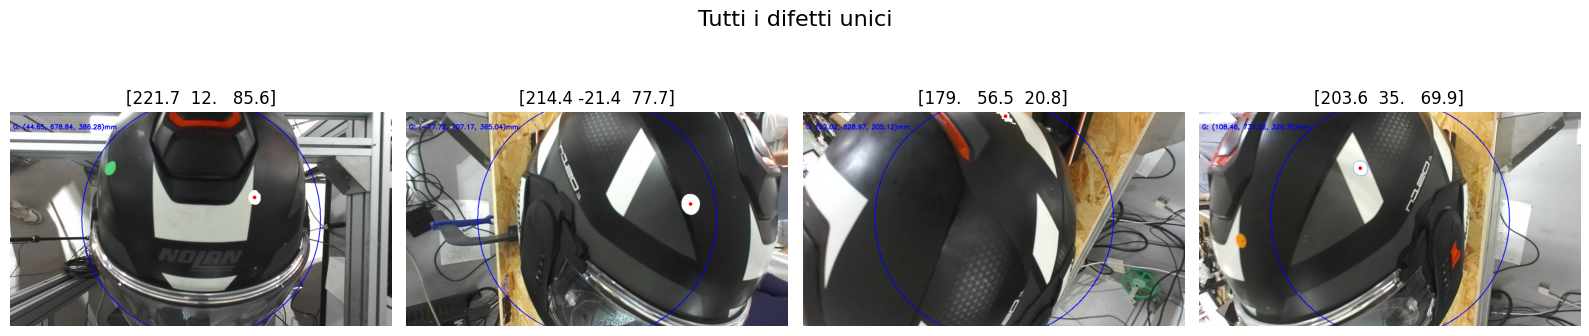

=== Tutti i difetti raffinati ===


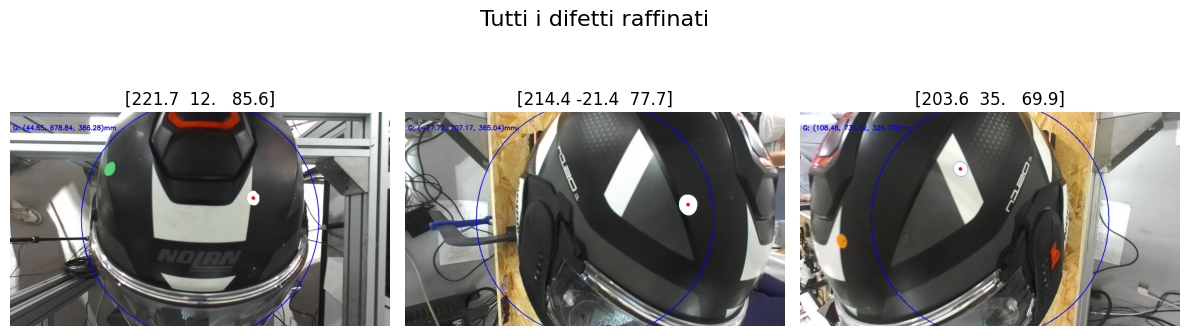

=== Tutti i difetti marcati ===


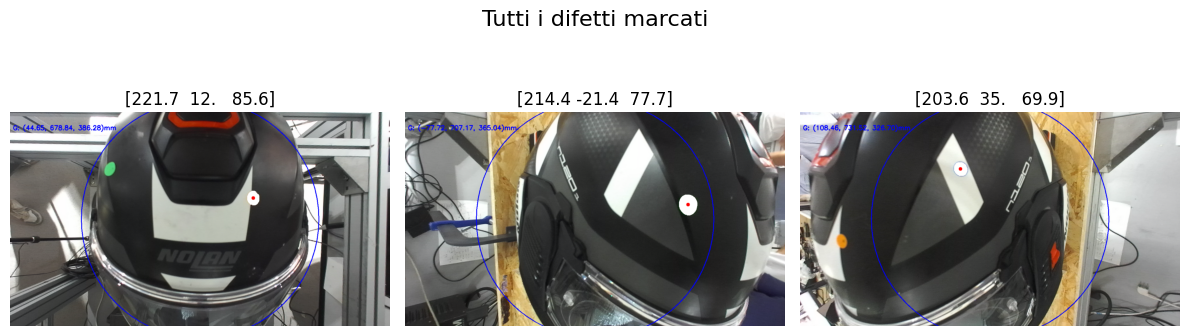

In [15]:

def show_defect_grid(defect_list, section_title):
    print(f"=== {section_title} ===")
    if len(defect_list) == 0:
        print(f"Nessun difetto {section_title.lower()} da visualizzare.")
        return

    n_defects = len(defect_list)
    cols = min(4, n_defects)
    rows = int(np.ceil(n_defects / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, d in zip(axes, defect_list):
        img = d.img()
        if img is None:
            ax.axis("off")
            continue

        if img.ndim == 3 and img.shape[-1] == 3:
            img = img[..., ::-1]

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(f"{np.round(d.sph_coord,1)}")
        ax.axis("off")

    for ax in axes[n_defects:]:
        ax.axis("off")

    fig.suptitle(section_title, fontsize=16)
    plt.tight_layout()
    plt.show()

show_defect_grid(unique_defects, "Tutti i difetti unici")
show_defect_grid(refined_defects, "Tutti i difetti raffinati")
show_defect_grid(marked_defects, "Tutti i difetti marcati")